In [1]:
import numpy as np
from IPython.display import Image, display
from sedona.spark import SedonaContext
import itertools
import os
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from sedona.stats.clustering.dbscan import dbscan
import math

In [2]:
additional_packages = [
    'org.apache.sedona:sedona-spark-3.5_2.12:1.7.1',
    'org.datasyslab:geotools-wrapper:1.7.1-28.5',
]

config_params = {
    "spark.jars.packages": ",".join(additional_packages),
    "spark.hadoop.fs.s3a.aws.credentials.provider": "org.apache.hadoop.fs.s3a.SimpleAWSCredentialsProvider",
}

if os.environ.get("SEDONA_COPY_MINIO") == "true":
    config_params = {
        **config_params,
        **{
            "spark.hadoop.fs.s3a.access.key": "sedona",
            "spark.hadoop.fs.s3a.secret.key": "sedona_password",
            "spark.hadoop.fs.s3a.endpoint": "http://minio:9000",
            "spark.hadoop.fs.s3a.impl": "org.apache.hadoop.fs.s3a.S3AFileSystem",
            "spark.hadoop.fs.s3a.path.style.access": "true"
        }
    }

bucket_name = os.environ.get("SEDONA_SOURCE_BUCKET", "apache-sedona-book")

config = SedonaContext.builder()

for key, value in config_params.items():
    config = config.config(key, value)

sedona = SedonaContext.create(config.getOrCreate())
sedona.sparkContext.setLogLevel("ERROR")

sedona.sparkContext.setCheckpointDir("checkpoint")

:: loading settings :: url = jar:file:/opt/spark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /root/.ivy2/cache
The jars for the packages stored in: /root/.ivy2/jars
org.apache.sedona#sedona-spark-3.5_2.12 added as a dependency
org.datasyslab#geotools-wrapper added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-6be84453-b7a6-44a4-b667-a9527f1baf99;1.0
	confs: [default]
	found org.apache.sedona#sedona-spark-3.5_2.12;1.7.1 in central
	found org.apache.sedona#sedona-common;1.7.1 in central
	found org.apache.commons#commons-math3;3.6.1 in central
	found org.locationtech.jts#jts-core;1.20.0 in central
	found org.wololo#jts2geojson;0.16.1 in central
	found org.locationtech.spatial4j#spatial4j;0.8 in central
	found com.google.geometry#s2-geometry;2.0.0 in central
	found com.google.guava#guava;25.1-jre in central
	found com.google.code.findbugs#jsr305;3.0.2 in central
	found org.checkerframework#checker-qual;2.0.0 in central
	found com.google.errorprone#error_prone_annotations;2.1.3 in central
	found com.google.j2objc#j2objc-

In [3]:
hotspot_data = sedona.read.format("geoparquet").load(f"s3a://{bucket_name}/source_data/hot_spot")

In [4]:
from sedona.spark import dataframe_to_arrow
import geopandas as gpd
 
gdf = gpd.GeoDataFrame.from_arrow(dataframe_to_arrow(hotspot_data))

<Axes: >

<Figure size 1800x600 with 0 Axes>

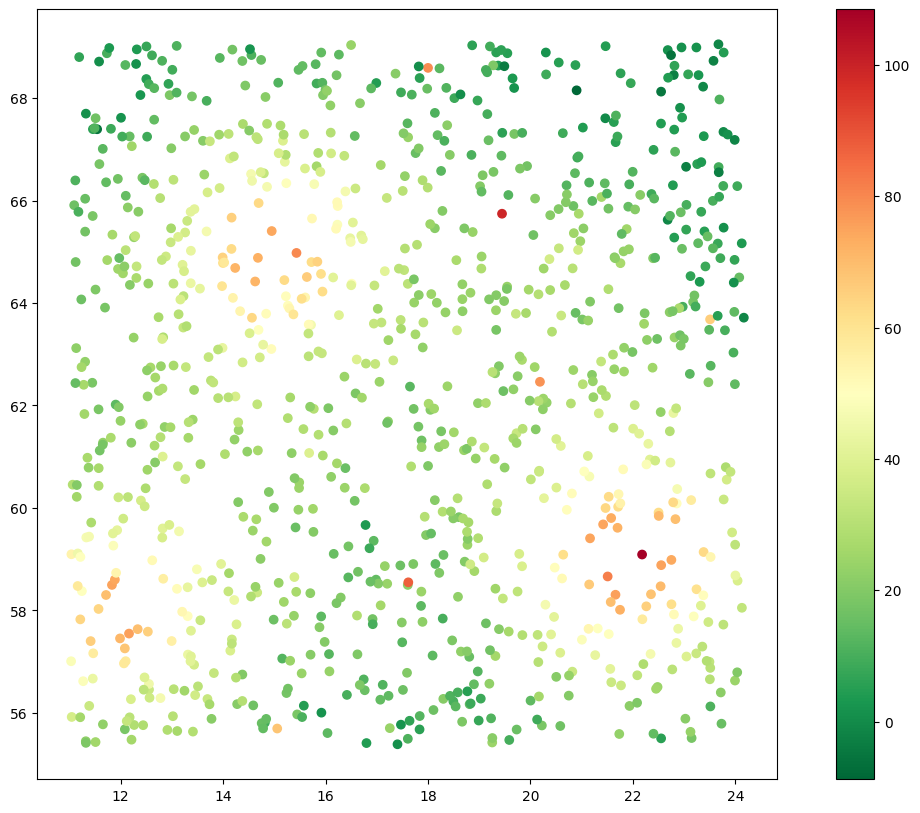

In [5]:
axis = plt.figure(figsize=(18, 6))

gdf.plot(column='value', cmap='RdYlGn_r', figsize=(15, 10), legend=True)

# calculate weights dataframe 

In [11]:
from sedona.stats.weighting import add_distance_band_column
from sedona.stats.hotspot_detection.getis_ord import g_local

In [12]:
weights_df = add_distance_band_column(
    dataframe=hotspot_data,
    threshold=2.0,
    include_self=True
)

In [13]:
gi_df = g_local(
    dataframe=weights_df,
    x="value",
    star=True
)

# plot result

In [ ]:
hotspot_gdf = gpd.GeoDataFrame.from_arrow(dataframe_to_arrow(gi_df))

<Axes: >

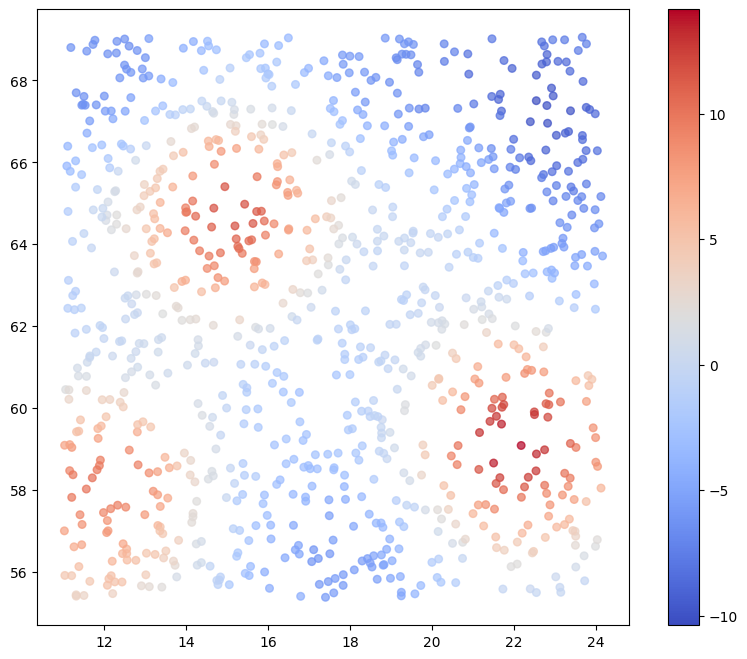

In [21]:
hotspot_gdf.plot(column='Z', cmap='coolwarm', figsize=(10,8), legend=True, marker='o', markersize=30, alpha=0.7)

### 